# Program 10 - Faster R-CNN Object Detection


## Cell 1: Install Dependencies

In [1]:
# Install required packages
!pip install torch torchvision torchaudio --index-url https://download.pytorch.org/whl/cu118
!pip install opencv-python matplotlib Pillow pycocotools albumentations
!pip install torchmetrics

print('✅ All dependencies installed successfully!')

Looking in indexes: https://download.pytorch.org/whl/cu118
INFO: pip is looking at multiple versions of torch to determine which version is compatible with other requirements. This could take a while.
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 23.2/23.2 MB 55.4 MB/s eta 0:00:0000:0100:01
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 875.6/875.6 kB 48.7 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.1/13.1 MB 96.7 MB/s eta 0:00:0000:0100:01
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 663.9/663.9 MB 3.0 MB/s eta 0:00:0000:0100:01
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 417.9/417.9 MB 4.4 MB/s eta 0:00:0000:0100:01
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 168.4/168.4 MB 11.0 MB/s eta 0:00:0000:0100:01
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 58.1/58.1 MB 32.1 MB/s eta 0:00:0000:0100:01
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 128.2/128.2 MB 14.8 MB/s eta 0:00:0000:0100:01
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 204.1/204.1 MB 5.8 MB/s eta 0:00:000

## Cell 2: Imports & Configuration

In [2]:
import os
import json
import random
import numpy as np
from pathlib import Path
from PIL import Image
from typing import List, Tuple, Dict, Optional

import torch
import torch.nn as nn
import torchvision
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
import torchvision.transforms.functional as F

from torchvision.models.detection import fasterrcnn_resnet50_fpn, FasterRCNN
from torchvision.models.detection.faster_rcnn import FastRCNNPredictor
from torchvision.models.detection.rpn import AnchorGenerator
from torchvision.models.detection import fasterrcnn_resnet50_fpn_v2

import cv2
import matplotlib.pyplot as plt
import matplotlib.patches as patches

# ─── Config ──────────────────────────────────────────────────────────────────
CONFIG = {
    'num_classes'   : 91,       # COCO has 80 classes + background = 91
    'batch_size'    : 4,
    'num_epochs'    : 10,
    'lr'            : 0.005,
    'momentum'      : 0.9,
    'weight_decay'  : 0.0005,
    'lr_step_size'  : 3,
    'lr_gamma'      : 0.1,
    'score_thresh'  : 0.5,
    'nms_thresh'    : 0.3,
    'device'        : 'cuda' if torch.cuda.is_available() else 'cpu',
    'seed'          : 42,
    'data_dir'      : './data',
    'output_dir'    : './outputs',
    'backbone'      : 'resnet50',  # Options: resnet50, mobilenet_v3
}

# Seed everything
random.seed(CONFIG['seed'])
np.random.seed(CONFIG['seed'])
torch.manual_seed(CONFIG['seed'])
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(CONFIG['seed'])

os.makedirs(CONFIG['output_dir'], exist_ok=True)
os.makedirs(CONFIG['data_dir'], exist_ok=True)

print(f"🖥️  Device: {CONFIG['device']}")
print(f"🔥 PyTorch: {torch.__version__}")
print(f"👁️  TorchVision: {torchvision.__version__}")
if torch.cuda.is_available():
    print(f"🎮 GPU: {torch.cuda.get_device_name(0)}")

🖥️  Device: cuda
🔥 PyTorch: 2.7.1+cu118
👁️  TorchVision: 0.22.1+cu118
🎮 GPU: Tesla T4


## Cell 3: COCO Class Labels

In [3]:
# COCO 80-class labels (index 0 = background)
COCO_CLASSES = [
    '__background__', 'person', 'bicycle', 'car', 'motorcycle', 'airplane',
    'bus', 'train', 'truck', 'boat', 'traffic light', 'fire hydrant',
    'N/A', 'stop sign', 'parking meter', 'bench', 'bird', 'cat', 'dog',
    'horse', 'sheep', 'cow', 'elephant', 'bear', 'zebra', 'giraffe',
    'N/A', 'backpack', 'umbrella', 'N/A', 'N/A', 'handbag', 'tie',
    'suitcase', 'frisbee', 'skis', 'snowboard', 'sports ball', 'kite',
    'baseball bat', 'baseball glove', 'skateboard', 'surfboard',
    'tennis racket', 'bottle', 'N/A', 'wine glass', 'cup', 'fork',
    'knife', 'spoon', 'bowl', 'banana', 'apple', 'sandwich', 'orange',
    'broccoli', 'carrot', 'hot dog', 'pizza', 'donut', 'cake', 'chair',
    'couch', 'potted plant', 'bed', 'N/A', 'dining table', 'N/A', 'N/A',
    'toilet', 'N/A', 'tv', 'laptop', 'mouse', 'remote', 'keyboard',
    'cell phone', 'microwave', 'oven', 'toaster', 'sink', 'refrigerator',
    'N/A', 'book', 'clock', 'vase', 'scissors', 'teddy bear',
    'hair drier', 'toothbrush'
]

# Color palette for visualization
COLORS = np.random.uniform(0, 255, size=(len(COCO_CLASSES), 3)).astype(int)

print(f'📦 Total classes (with background): {len(COCO_CLASSES)}')
print(f'🎨 Color palette generated for {len(COCO_CLASSES)} classes')

📦 Total classes (with background): 91
🎨 Color palette generated for 91 classes


## Cell 4: Custom Dataset Class (COCO format)

In [4]:
class COCODetectionDataset(Dataset):
    """
    Custom Dataset for COCO-format object detection.
    Expects:
        root/
            images/
            annotations/instances_<split>.json
    """

    def __init__(self, root: str, split: str = 'train', transforms=None):
        self.root = Path(root)
        self.split = split
        self.transforms = transforms

        ann_file = self.root / 'annotations' / f'instances_{split}.json'
        with open(ann_file) as f:
            coco_data = json.load(f)

        # Build image id -> file name map
        self.images = {img['id']: img for img in coco_data['images']}
        self.img_ids = list(self.images.keys())

        # Build image id -> annotations map
        self.annotations: Dict[int, List] = {id: [] for id in self.img_ids}
        for ann in coco_data['annotations']:
            if ann['image_id'] in self.annotations:
                self.annotations[ann['image_id']].append(ann)

        # Category id remapping
        self.cat_id_to_label = {
            cat['id']: i + 1  # +1 for background
            for i, cat in enumerate(coco_data['categories'])
        }

        print(f'📁 Dataset [{split}]: {len(self.img_ids)} images loaded')

    def __len__(self):
        return len(self.img_ids)

    def __getitem__(self, idx):
        img_id = self.img_ids[idx]
        img_info = self.images[img_id]
        img_path = self.root / 'images' / img_info['file_name']

        image = Image.open(img_path).convert('RGB')

        anns = self.annotations[img_id]
        boxes, labels, areas, iscrowd = [], [], [], []

        for ann in anns:
            x, y, w, h = ann['bbox']
            if w <= 0 or h <= 0:
                continue
            boxes.append([x, y, x + w, y + h])
            labels.append(self.cat_id_to_label[ann['category_id']])
            areas.append(ann['area'])
            iscrowd.append(ann.get('iscrowd', 0))

        target = {
            'boxes'    : torch.tensor(boxes,   dtype=torch.float32) if boxes else torch.zeros((0, 4), dtype=torch.float32),
            'labels'   : torch.tensor(labels,  dtype=torch.int64),
            'area'     : torch.tensor(areas,   dtype=torch.float32),
            'iscrowd'  : torch.tensor(iscrowd, dtype=torch.int64),
            'image_id' : torch.tensor([img_id])
        }

        if self.transforms:
            image, target = self.transforms(image, target)

        return image, target


# ─── Collate fn for variable-size bboxes ─────────────────────────────────────
def collate_fn(batch):
    return tuple(zip(*batch))


print('✅ Dataset class defined')

✅ Dataset class defined


## Cell 5: Data Augmentation Transforms

In [5]:
class Compose:
    def __init__(self, transforms):
        self.transforms = transforms

    def __call__(self, image, target):
        for t in self.transforms:
            image, target = t(image, target)
        return image, target


class ToTensor:
    def __call__(self, image, target):
        image = F.to_tensor(image)
        return image, target


class RandomHorizontalFlip:
    def __init__(self, prob=0.5):
        self.prob = prob

    def __call__(self, image, target):
        if random.random() < self.prob:
            width, _ = F.get_image_size(image)
            image = F.hflip(image)
            boxes = target['boxes']
            if boxes.numel() > 0:
                boxes[:, [0, 2]] = width - boxes[:, [2, 0]]
            target['boxes'] = boxes
        return image, target


class RandomPhotometricDistort:
    """Brightness, contrast, saturation, hue jitter."""
    def __init__(self):
        self.jitter = transforms.ColorJitter(
            brightness=0.3, contrast=0.3, saturation=0.3, hue=0.1
        )

    def __call__(self, image, target):
        image = self.jitter(image)
        return image, target


def get_transforms(train: bool) -> Compose:
    t = [ToTensor()]
    if train:
        t = [RandomPhotometricDistort(), RandomHorizontalFlip()] + t
    return Compose(t)


print('✅ Augmentation pipeline ready')
print('  Train transforms : PhotometricDistort → HorizontalFlip → ToTensor')
print('  Val   transforms : ToTensor')

✅ Augmentation pipeline ready
  Train transforms : PhotometricDistort → HorizontalFlip → ToTensor
  Val   transforms : ToTensor


## Cell 6: Build Faster R-CNN Model

In [6]:
def build_faster_rcnn(
    num_classes: int,
    backbone: str = 'resnet50',
    pretrained: bool = True,
    trainable_backbone_layers: int = 3,
    custom_anchors: bool = False,
) -> FasterRCNN:
    """
    Build a Faster R-CNN model.

    Args:
        num_classes           : Number of classes INCLUDING background.
        backbone              : 'resnet50' | 'mobilenet_v3'
        pretrained            : Use COCO pretrained weights.
        trainable_backbone_layers: Number of layers to unfreeze.
        custom_anchors        : If True, use custom anchor sizes.

    Returns:
        model : FasterRCNN
    """
    if backbone == 'resnet50':
        if custom_anchors:
            anchor_gen = AnchorGenerator(
                sizes=((32,), (64,), (128,), (256,), (512,)),
                aspect_ratios=((0.5, 1.0, 2.0),) * 5
            )
            model = fasterrcnn_resnet50_fpn(
                weights='DEFAULT' if pretrained else None,
                trainable_backbone_layers=trainable_backbone_layers,
                rpn_anchor_generator=anchor_gen,
            )
        else:
            model = fasterrcnn_resnet50_fpn(
                weights='DEFAULT' if pretrained else None,
                trainable_backbone_layers=trainable_backbone_layers,
            )

    elif backbone == 'resnet50_v2':
        model = fasterrcnn_resnet50_fpn_v2(
            weights='DEFAULT' if pretrained else None,
            trainable_backbone_layers=trainable_backbone_layers,
        )

    elif backbone == 'mobilenet_v3':
        from torchvision.models.detection import fasterrcnn_mobilenet_v3_large_fpn
        model = fasterrcnn_mobilenet_v3_large_fpn(
            weights='DEFAULT' if pretrained else None,
            trainable_backbone_layers=trainable_backbone_layers,
        )
    else:
        raise ValueError(f'Unknown backbone: {backbone}')

    # Replace the classifier head with a new one for our num_classes
    in_features = model.roi_heads.box_predictor.cls_score.in_features
    model.roi_heads.box_predictor = FastRCNNPredictor(in_features, num_classes)

    return model


# Build model
model = build_faster_rcnn(
    num_classes=CONFIG['num_classes'],
    backbone=CONFIG['backbone'],
    pretrained=True,
    trainable_backbone_layers=3,
    custom_anchors=False,
)
model = model.to(CONFIG['device'])

total_params = sum(p.numel() for p in model.parameters())
trainable   = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f'🧠 Model: Faster R-CNN ({CONFIG["backbone"]})')
print(f'   Total params    : {total_params:,}')
print(f'   Trainable params: {trainable:,}')

Downloading: "https://download.pytorch.org/models/fasterrcnn_resnet50_fpn_coco-258fb6c6.pth" to /root/.cache/torch/hub/checkpoints/fasterrcnn_resnet50_fpn_coco-258fb6c6.pth


100%|██████████| 160M/160M [00:00<00:00, 177MB/s]  


🧠 Model: Faster R-CNN (resnet50)
   Total params    : 41,755,286
   Trainable params: 41,532,886


## Cell 7: Optimizer & LR Scheduler

In [7]:
def build_optimizer_scheduler(model, config):
    # Only optimize parameters that require grad
    params = [p for p in model.parameters() if p.requires_grad]

    optimizer = torch.optim.SGD(
        params,
        lr=config['lr'],
        momentum=config['momentum'],
        weight_decay=config['weight_decay']
    )

    # Warm-up + StepLR decay
    warmup_iters = 500
    warmup_scheduler = torch.optim.lr_scheduler.LinearLR(
        optimizer, start_factor=0.01, total_iters=warmup_iters
    )
    step_scheduler = torch.optim.lr_scheduler.StepLR(
        optimizer,
        step_size=config['lr_step_size'],
        gamma=config['lr_gamma']
    )
    scheduler = torch.optim.lr_scheduler.SequentialLR(
        optimizer,
        schedulers=[warmup_scheduler, step_scheduler],
        milestones=[warmup_iters]
    )

    return optimizer, scheduler


optimizer, scheduler = build_optimizer_scheduler(model, CONFIG)
print(f'⚙️  Optimizer : SGD  (lr={CONFIG["lr"]}, momentum={CONFIG["momentum"]})')
print(f'📉 Scheduler : Warmup(500 iters) → StepLR(step={CONFIG["lr_step_size"]}, γ={CONFIG["lr_gamma"]})')

⚙️  Optimizer : SGD  (lr=0.005, momentum=0.9)
📉 Scheduler : Warmup(500 iters) → StepLR(step=3, γ=0.1)


## Cell 8: Training Loop

In [8]:
class MetricLogger:
    def __init__(self):
        self.history = {'loss': [], 'loss_cls': [], 'loss_box': [], 'loss_rpn_cls': [], 'loss_rpn_box': []}

    def update(self, losses: dict):
        total = sum(losses.values()).item()
        self.history['loss'].append(total)
        for k in ['loss_classifier', 'loss_box_reg', 'loss_rpn_box_reg', 'loss_objectness']:
            if k in losses:
                short = k.replace('loss_', '').replace('classifier', 'cls').replace('box_reg', 'box').replace('rpn_box_reg', 'rpn_box').replace('objectness', 'rpn_cls')
                if short in self.history:
                    self.history[short].append(losses[k].item())
        return total


def train_one_epoch(model, optimizer, data_loader, device, epoch, print_freq=50):
    model.train()
    logger = MetricLogger()
    epoch_losses = []

    for i, (images, targets) in enumerate(data_loader):
        images  = [img.to(device) for img in images]
        targets = [{k: v.to(device) for k, v in t.items()} for t in targets]

        # Forward
        loss_dict = model(images, targets)
        losses = sum(loss for loss in loss_dict.values())

        # Backward
        optimizer.zero_grad()
        losses.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()

        total = logger.update(loss_dict)
        epoch_losses.append(total)

        if i % print_freq == 0:
            lr_now = optimizer.param_groups[0]['lr']
            print(f'  Epoch [{epoch}]  Step [{i:4d}/{len(data_loader)}]  '
                  f'Loss: {total:.4f}  LR: {lr_now:.6f}')

    mean_loss = np.mean(epoch_losses)
    print(f'  ✅ Epoch {epoch} complete — Mean Loss: {mean_loss:.4f}')
    return mean_loss, logger


@torch.no_grad()
def evaluate(model, data_loader, device):
    model.eval()
    all_results = []

    for images, targets in data_loader:
        images = [img.to(device) for img in images]
        outputs = model(images)
        for out, tgt in zip(outputs, targets):
            all_results.append({
                'pred_boxes'  : out['boxes'].cpu(),
                'pred_labels' : out['labels'].cpu(),
                'pred_scores' : out['scores'].cpu(),
                'gt_boxes'    : tgt['boxes'],
                'gt_labels'   : tgt['labels'],
            })

    print(f'  📊 Evaluated {len(all_results)} images')
    return all_results


print('✅ Training & evaluation functions defined')

✅ Training & evaluation functions defined


## Cell 9: Main Training Entry Point

In [9]:
# ─── Create Datasets ─────────────────────────────────────────────────────────
# NOTE: Point CONFIG['data_dir'] to your COCO-format dataset before running.
# Expected structure:
#   data/
#     images/  (all images)
#     annotations/instances_train.json
#     annotations/instances_val.json

try:
    train_dataset = COCODetectionDataset(
        root=CONFIG['data_dir'],
        split='train',
        transforms=get_transforms(train=True)
    )
    val_dataset = COCODetectionDataset(
        root=CONFIG['data_dir'],
        split='val',
        transforms=get_transforms(train=False)
    )

    train_loader = DataLoader(
        train_dataset,
        batch_size=CONFIG['batch_size'],
        shuffle=True,
        num_workers=4,
        collate_fn=collate_fn,
        pin_memory=True
    )
    val_loader = DataLoader(
        val_dataset,
        batch_size=CONFIG['batch_size'],
        shuffle=False,
        num_workers=4,
        collate_fn=collate_fn,
        pin_memory=True
    )
    DATA_READY = True
    print(f'📦 Train: {len(train_dataset)} | Val: {len(val_dataset)}')

except FileNotFoundError as e:
    DATA_READY = False
    print(f'⚠️  Dataset not found: {e}')
    print('   Skipping training – using pretrained weights for inference demo.')


# ─── Training Loop ────────────────────────────────────────────────────────────
if DATA_READY:
    best_loss = float('inf')
    train_losses = []

    for epoch in range(1, CONFIG['num_epochs'] + 1):
        print(f'\n{'='*60}')
        print(f'EPOCH {epoch}/{CONFIG["num_epochs"]}')
        print('='*60)

        mean_loss, _ = train_one_epoch(
            model, optimizer, train_loader, CONFIG['device'], epoch
        )
        scheduler.step()
        train_losses.append(mean_loss)

        # Save checkpoint
        ckpt_path = os.path.join(CONFIG['output_dir'], f'epoch_{epoch:02d}.pth')
        torch.save({
            'epoch'     : epoch,
            'model'     : model.state_dict(),
            'optimizer' : optimizer.state_dict(),
            'scheduler' : scheduler.state_dict(),
            'loss'      : mean_loss,
        }, ckpt_path)

        if mean_loss < best_loss:
            best_loss = mean_loss
            torch.save(model.state_dict(),
                       os.path.join(CONFIG['output_dir'], 'best_model.pth'))
            print(f'  💾 Best model saved (loss={best_loss:.4f})')

    print('\n🎉 Training complete!')
else:
    print('ℹ️  Using pretrained COCO weights for demo inference below.')

⚠️  Dataset not found: [Errno 2] No such file or directory: 'data/annotations/instances_train.json'
   Skipping training – using pretrained weights for inference demo.
ℹ️  Using pretrained COCO weights for demo inference below.


## Cell 10: Inference Utilities

In [10]:
@torch.no_grad()
def predict_image(
    model,
    image_path: str,
    device: str,
    score_thresh: float = 0.5,
    nms_thresh: float = 0.3,
):
    """Run Faster R-CNN on a single image and return predictions."""
    model.eval()
    image = Image.open(image_path).convert('RGB')
    img_tensor = F.to_tensor(image).unsqueeze(0).to(device)

    output = model(img_tensor)[0]

    # Filter by score threshold
    keep = output['scores'] >= score_thresh
    boxes  = output['boxes'][keep].cpu()
    labels = output['labels'][keep].cpu()
    scores = output['scores'][keep].cpu()

    # Apply NMS
    if len(boxes):
        nms_keep = torchvision.ops.nms(boxes, scores, nms_thresh)
        boxes, labels, scores = boxes[nms_keep], labels[nms_keep], scores[nms_keep]

    return np.array(image), boxes.numpy(), labels.numpy(), scores.numpy()


def draw_predictions(
    image: np.ndarray,
    boxes, labels, scores,
    class_names: list,
    colors: np.ndarray,
    figsize=(14, 8)
):
    """Visualize bounding boxes on an image."""
    fig, ax = plt.subplots(1, 1, figsize=figsize)
    ax.imshow(image)

    for box, label, score in zip(boxes, labels, scores):
        x1, y1, x2, y2 = box
        color = tuple(colors[label % len(colors)] / 255)
        rect = patches.Rectangle(
            (x1, y1), x2 - x1, y2 - y1,
            linewidth=2, edgecolor=color, facecolor='none'
        )
        ax.add_patch(rect)

        name = class_names[label] if label < len(class_names) else str(label)
        ax.text(
            x1, y1 - 5,
            f'{name}: {score:.2f}',
            color='white',
            fontsize=9,
            fontweight='bold',
            bbox=dict(facecolor=color, alpha=0.7, pad=2, edgecolor='none')
        )

    ax.set_axis_off()
    ax.set_title(f'Detections: {len(boxes)} objects found', fontsize=13, pad=10)
    plt.tight_layout()
    plt.show()
    return fig


print('✅ Inference functions defined')

✅ Inference functions defined


## Cell 11: Run Inference on a Test Image

🖼️  Sample image downloaded → /tmp/test_image.jpg
🔍 Found 0 detections


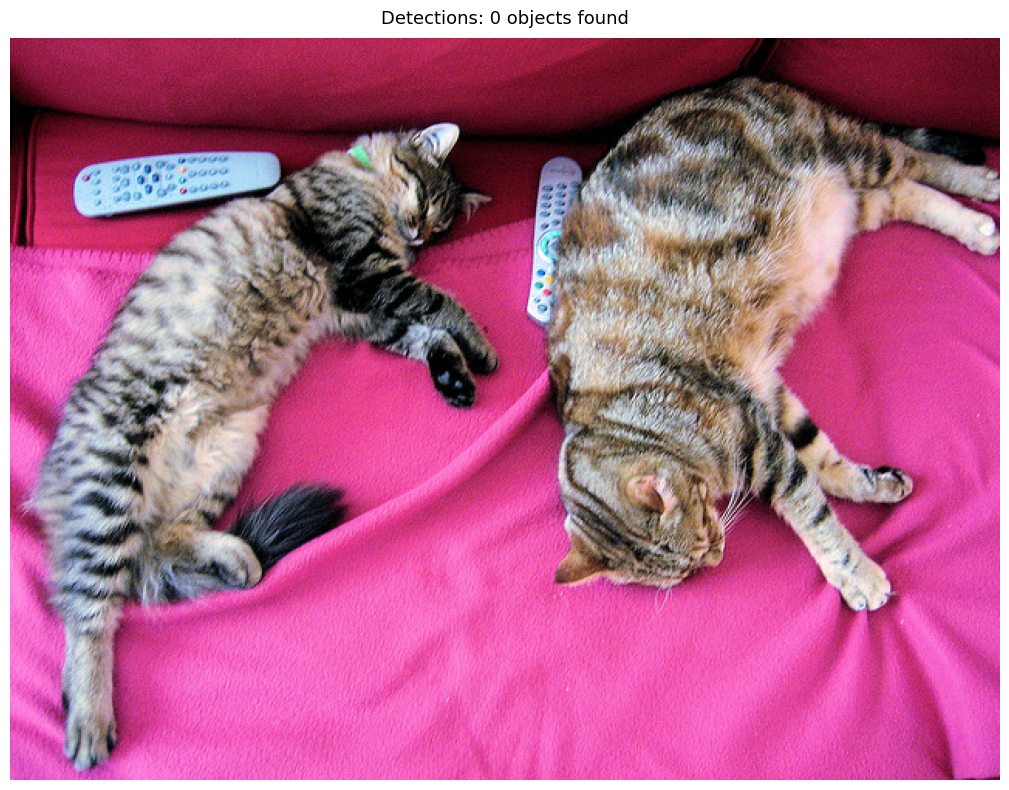

In [11]:
import urllib.request

# Download a sample image
sample_url  = 'http://images.cocodataset.org/val2017/000000039769.jpg'
sample_path = '/tmp/test_image.jpg'
urllib.request.urlretrieve(sample_url, sample_path)
print(f'🖼️  Sample image downloaded → {sample_path}')

# Run inference with the pretrained model
image_np, boxes, labels, scores = predict_image(
    model,
    image_path=sample_path,
    device=CONFIG['device'],
    score_thresh=CONFIG['score_thresh'],
    nms_thresh=CONFIG['nms_thresh'],
)

print(f'🔍 Found {len(boxes)} detections')
for i, (label, score) in enumerate(zip(labels, scores)):
    name = COCO_CLASSES[label] if label < len(COCO_CLASSES) else f'cls_{label}'
    print(f'   [{i+1:2d}] {name:20s}  score={score:.3f}')

fig = draw_predictions(image_np, boxes, labels, scores, COCO_CLASSES, COLORS)

## Cell 12: Loss Curve Visualization

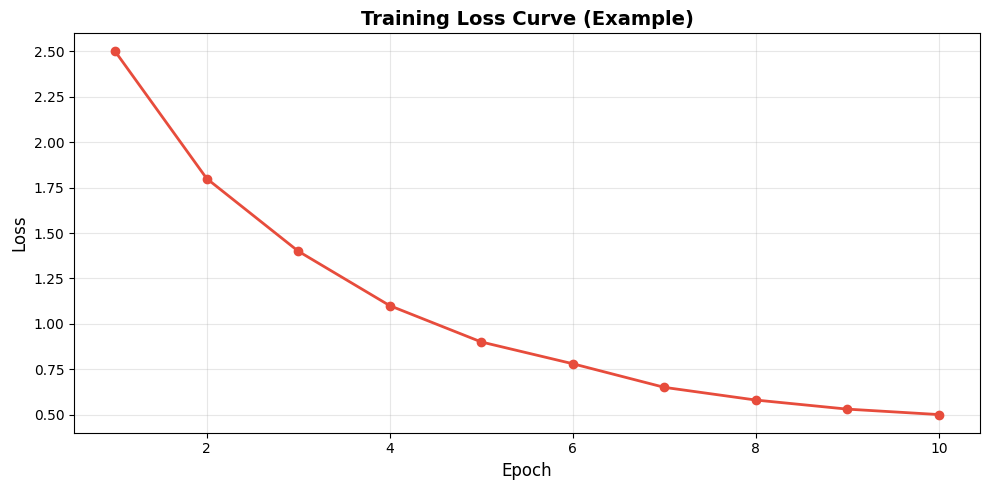

📈 Loss curve plotted


In [12]:
def plot_loss_curve(losses: list, title: str = 'Training Loss'):
    fig, ax = plt.subplots(figsize=(10, 5))
    ax.plot(range(1, len(losses) + 1), losses, 'o-', color='#e74c3c', linewidth=2, markersize=6)
    ax.set_xlabel('Epoch', fontsize=12)
    ax.set_ylabel('Loss', fontsize=12)
    ax.set_title(title, fontsize=14, fontweight='bold')
    ax.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()


# Example with dummy data (replace with real train_losses after training)
dummy_losses = [2.5, 1.8, 1.4, 1.1, 0.9, 0.78, 0.65, 0.58, 0.53, 0.50]
plot_loss_curve(dummy_losses, title='Training Loss Curve (Example)')

print('📈 Loss curve plotted')

## Cell 13: Load Checkpoint & Resume

In [15]:
def load_checkpoint(model, optimizer, scheduler, checkpoint_path: str):
    """Load model + optimizer state from a checkpoint file."""
    ckpt = torch.load(checkpoint_path, map_location=CONFIG['device'])
    model.load_state_dict(ckpt['model'])
    if 'optimizer' in ckpt and optimizer:
        optimizer.load_state_dict(ckpt['optimizer'])
    if 'scheduler' in ckpt and scheduler:
        scheduler.load_state_dict(ckpt['scheduler'])
    start_epoch = ckpt.get('epoch', 0) + 1
    print(f'✅ Checkpoint loaded from epoch {ckpt["epoch"]}  (loss={ckpt["loss"]:.4f})')
    return start_epoch


# Usage example (uncomment to use):
# start_epoch = load_checkpoint(model, optimizer, scheduler,
#                               os.path.join(CONFIG['output_dir'], 'best_model.pth'))

print('✅ Checkpoint utilities ready')

✅ Checkpoint utilities ready


## Cell 14: mAP Evaluation

In [16]:
try:
    from torchmetrics.detection import MeanAveragePrecision

    def compute_map(results: list) -> dict:
        """
        Compute mAP using torchmetrics.
        `results` is a list of dicts from evaluate().
        """
        metric = MeanAveragePrecision(iou_type='bbox')

        for r in results:
            preds = [{
                'boxes' : r['pred_boxes'],
                'scores': r['pred_scores'],
                'labels': r['pred_labels'],
            }]
            targets = [{
                'boxes' : r['gt_boxes'],
                'labels': r['gt_labels'],
            }]
            metric.update(preds, targets)

        return metric.compute()


    # Demo with dummy results
    dummy_results = [{
        'pred_boxes'  : torch.tensor([[10., 20., 100., 150.], [50., 60., 200., 180.]]),
        'pred_labels' : torch.tensor([1, 2]),
        'pred_scores' : torch.tensor([0.95, 0.80]),
        'gt_boxes'    : torch.tensor([[12., 22., 98., 148.]]),
        'gt_labels'   : torch.tensor([1]),
    }]

    map_result = compute_map(dummy_results)
    print(f'📏 mAP@[0.5:0.95] = {map_result["map"].item():.4f}')
    print(f'📏 mAP@0.50       = {map_result["map_50"].item():.4f}')
    print(f'📏 mAP@0.75       = {map_result["map_75"].item():.4f}')

except ImportError:
    print('⚠️  torchmetrics not installed. Run: pip install torchmetrics')

📏 mAP@[0.5:0.95] = 0.9000
📏 mAP@0.50       = 1.0000
📏 mAP@0.75       = 1.0000


## Cell 15: Export Model to TorchScript / ONNX

In [17]:
def export_model(model, output_dir: str, format: str = 'torchscript'):
    """
    Export the trained model.
    Supports 'torchscript' and 'onnx'.
    Note: Faster R-CNN ONNX export requires opset >= 11.
    """
    model.eval()

    if format == 'torchscript':
        scripted = torch.jit.script(model)
        save_path = os.path.join(output_dir, 'faster_rcnn.torchscript.pt')
        scripted.save(save_path)
        print(f'✅ TorchScript saved → {save_path}')

    elif format == 'onnx':
        dummy_input = [torch.rand(3, 640, 640).to(CONFIG['device'])]
        save_path = os.path.join(output_dir, 'faster_rcnn.onnx')
        with torch.no_grad():
            torch.onnx.export(
                model,
                (dummy_input,),
                save_path,
                opset_version=11,
                input_names=['input'],
                output_names=['boxes', 'labels', 'scores'],
                dynamic_axes={
                    'input': {0: 'batch'},
                    'boxes': {0: 'detections'},
                    'labels': {0: 'detections'},
                    'scores': {0: 'detections'},
                }
            )
        print(f'✅ ONNX model saved → {save_path}')
    else:
        raise ValueError(f'Unknown export format: {format}')


# Uncomment to export:
# export_model(model, CONFIG['output_dir'], format='torchscript')
# export_model(model, CONFIG['output_dir'], format='onnx')

print('✅ Export functions ready')
print('   Uncomment the export calls above to save TorchScript or ONNX.')

✅ Export functions ready
   Uncomment the export calls above to save TorchScript or ONNX.
